# making a data for our classification!

In [20]:
from sklearn.datasets import make_circles

sample=1000

x , y =make_circles(sample,
                    noise=0.04,
                   )



In [21]:
import pandas as pd 


circle=pd.DataFrame({"X1": x[:, 0],
    "X2": x[:, 1],
    "label": y
})

circle.head()


,X1,X2,label
0,-0.664360,-0.470297,1
1,-0.535443,0.872793,0
2,-0.296947,-0.962478,0
3,-0.746980,-0.393673,1
4,0.517725,-0.837419,0


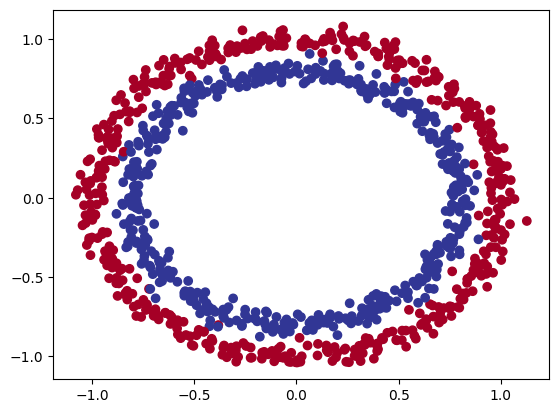

In [27]:
import matplotlib.pyplot as plt

plt.scatter(x=x[:,0],
            y=x[:,1],
            c=y,
            cmap="RdYlBu")

# turning  NP Arr -> Tensors


In [35]:
import torch 

X= torch.from_numpy(x).type(torch.float)
Y=torch.from_numpy(y).type(torch.float)


torch.Size([1000])

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,
                                                  Y,
                                                  test_size=0.2,
                                                  random_state=42)

# Make the model

In [47]:
import torch 
from torch import nn
device = "cpu"

In [50]:
class Circle(nn.Module):
    def __init__(self):
        super().__init__()
        self.Layer1=nn.Linear(2,5)# first layer 
        self.Layer2=nn.Linear(5,1)# hidden leyer that has output of Y

    def forward(self,x):
        return self.Layer2(self.Layer1(x))

         
model0=Circle().to(device)
model0
        
        

Circle(
  (Layer1): Linear(in_features=2, out_features=5, bias=True)
  (Layer2): Linear(in_features=5, out_features=1, bias=True)
)

# loss function and optimiziation

In [51]:
loss_func=nn.BCEWithLogitsLoss # difference is that this
                               #loss already has sigmoid in it

optim=torch.optim.SGD(params=model0.parameters(),
                      lr=0.1)

# accuracy

In [52]:
def accuracy(real,predict):
    correct_guess=torch.eq(y_true, y_pred).sum().item()
    return (correct_guess/len(predict))*100

## training